<a href="https://colab.research.google.com/github/Rishabh-0408/Data-Science-and-AI/blob/main/Dimension%20Reduction/LDA/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

In [ ]:
# Loading the Datasets

In [ ]:
wine = load_wine()

In [ ]:
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
# Lets Create a DataFrame

In [ ]:
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [ ]:
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
df = pd.DataFrame(wine.data,columns=wine.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# We will add the target colummn to my datasets

In [ ]:
df['target'] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
print(f'How many wines type we have in our data: {wine.target_names}')

How many wines type we have in our data: ['class_0' 'class_1' 'class_2']


In [ ]:
df.shape

(178, 14)

In [ ]:
# Shape Analysis
print(f'Rows: {df.shape[0]} and Colums : {df.shape[1]}')

Rows: 178 and Colums : 14


In [ ]:
# Descriptive Analysis

In [ ]:
df.describe().T # T stands for Transpose

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [ ]:
# Since in our data , Proline and Magnesium have STD as Compared to others , We can Standradize the data / Normarlize

In [ ]:
# PreProcessing

In [ ]:
x =  df.drop('target', axis = 1)
y = df['target']

In [ ]:
x.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [ ]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: target
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


**Let's Split the data into trainig and testing data**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Scale the data (standardization)**

this make mean = 0 and variance = 1 for all feature




In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Now my data is ready for LDA**

In [ ]:
print(f'Mean of First Feature after scaling : {np.mean(x_train_scaled[:,0]):.2f}')
print(f'Standard Deviation of First Feature after scaling : {np.std(x_train_scaled[:,0]):.2f}')

Mean of First Feature after scaling : 0.00
Standard Deviation of First Feature after scaling : 1.00


In [ ]:
x_train_scaled

array([[ 1.66529275, -0.60840587,  1.21896194, ..., -1.65632857,
        -0.87940904, -0.24860607],
       [-0.54952506,  2.7515415 ,  1.00331502, ..., -0.58463272,
        -1.25462095, -0.72992237],
       [-0.74531007, -1.14354109, -0.93750727, ...,  0.35845962,
         0.2462267 , -0.24860607],
       ...,
       [ 1.714239  , -0.44172441,  0.06884503, ...,  1.04434496,
         0.56585166,  2.69572196],
       [-0.35374006, -0.7399965 , -0.36244882, ...,  0.01551695,
        -0.74044166, -0.79631083],
       [-0.78201975,  0.06709269,  0.35637426, ..., -0.67036839,
         1.09392769, -0.98551793]])

**The LDA Transformation**

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2) # n_compnents = 2 means we are reducing the total features into two linear dimension

Now, Let's Train the model and Transform the data

In [ ]:
x_train_scaled[:5]

array([[ 1.66529275, -0.60840587,  1.21896194,  1.60540017, -0.16738426,
         0.80400157, -0.6916784 ,  1.26722552,  1.8775398 ,  3.41947305,
        -1.65632857, -0.87940904, -0.24860607],
       [-0.54952506,  2.7515415 ,  1.00331502,  1.60540017, -0.30437887,
        -0.78538376, -1.40123291,  2.04959953, -0.87350523, -0.0248012 ,
        -0.58463272, -1.25462095, -0.72992237],
       [-0.74531007, -1.14354109, -0.93750727, -0.28270426, -0.8523573 ,
         1.93702874,  1.7467906 , -1.00165913,  0.58798744, -0.24006834,
         0.35845962,  0.2462267 , -0.24860607],
       [ 0.61294837, -0.61717858,  1.00331502,  0.87920616, -0.78385999,
         0.4892718 , -0.90154664,  1.18898812,  1.17258451,  2.8813052 ,
        -1.65632857, -1.12955031, -0.38138298],
       [ 0.11124931, -0.76631462, -0.93750727, -1.15413707, -0.16738426,
         0.17454204,  0.63748708, -0.68870952, -0.40926638, -0.58449577,
         0.95860929,  0.1350528 ,  0.94638614]])

In [ ]:
x_train_lda = lda.fit_transform(x_train_scaled, y_train) # we are passing traget value, becuase we need to find the axes with max separation between classes
x_test_lda = lda.transform(x_test_scaled)

In [ ]:
x_train_lda[:5]

array([[ 5.43777422,  2.52448581],
       [ 4.90569395,  0.26747175],
       [-2.12803752, -2.28947542],
       [ 5.44251596,  2.0198157 ],
       [-3.07075432,  0.07373239]])

**Lets perform separation Information**

In [ ]:
exp_var = lda.explained_variance_ratio_
print(f'exp var by LD1: {exp_var[0] * 100:.2f}%')
print(f'exp var by LD2: {exp_var[1] * 100:.2f}%')
print(f'Total Information we are retaining: {sum(exp_var) * 100}%')

exp var by LD1: 71.43%
exp var by LD2: 28.57%
Total Information we are retaining: 100.0%


**Insight**

LD1 and LD2 preserves ccomplete 100% of the classes seapration information
. which means that we are removing 11 dimensions of just Noise and kept only the useful dimension (LD1 and LD2)

###**Let's Visulize the speration**

First of all, let's define the colurs and labels of 3 wines

In [ ]:
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [ ]:
colors= ['red', 'blue', 'green']
wine_name = wine.target_names

print(colors)
print(wine_name)

['red', 'blue', 'green']
['class_0' 'class_1' 'class_2']


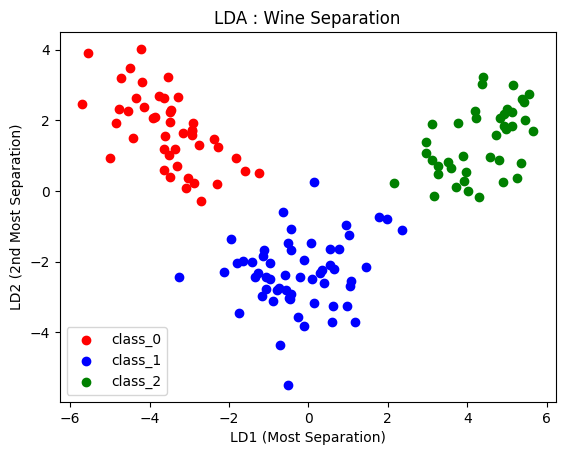

In [ ]:
for i, color, name in zip([0,1,2], colors, wine_name):
  plt.scatter(
      x_train_lda[y_train == i, 0], # x axis with LD1
      x_train_lda[y_train == i, 1], # y axis with LD2
      color = color,
      label = name
  )

plt.xlabel('LD1 (Most Separation)')
plt.ylabel('LD2 (2nd Most Separation)')
plt.title("LDA : Wine Separation")
plt.legend()
plt.show()

###**To Identify Which Features were actually Mattered?**

We need to check the coffecients

In [ ]:
coefficients = lda.scalings_[:, 0] #LD1

In [ ]:
coefficients

array([-3.02791428e-01,  2.68363423e-01, -1.50888271e-01,  5.74118380e-01,
       -1.35649108e-04,  4.23585503e-01, -1.59067596e+00, -2.03363473e-01,
        9.81488403e-03,  8.66871203e-01, -1.30475790e-01, -8.95701343e-01,
       -7.96189969e-01])

In [ ]:
feature_importance = pd.DataFrame({
    'Features': wine.feature_names,
    'Importance (LD1)': coefficients
})
feature_importance

,Features,Importance (LD1)
0,alcohol,-0.302791
1,malic_acid,0.268363
2,ash,-0.150888
3,alcalinity_of_ash,0.574118
4,magnesium,-0.000136
5,total_phenols,0.423586
6,flavanoids,-1.590676
7,nonflavanoid_phenols,-0.203363
8,proanthocyanins,0.009815
9,color_intensity,0.866871


**Now we will sort them by absolute value to see the most important features**

In [ ]:
feature_importance['Abs_Importance'] = feature_importance['Importance (LD1)'].abs()
feature_importance = feature_importance.sort_values(by = 'Abs_Importance', ascending = False)

In [ ]:
feature_importance.head()

,Features,Importance (LD1),Abs_Importance
6,flavanoids,-1.590676,1.590676
11,od280/od315_of_diluted_wines,-0.895701,0.895701
9,color_intensity,0.866871,0.866871
12,proline,-0.796190,0.796190
3,alcalinity_of_ash,0.574118,0.574118


**Summary**
1. Loaded the Data: We had in total 13 dimensional dataset
2. Standardized: Mean --> 0 and STD --> 1
3. Applied LDA: Calculated the best axes to find the wine classes
4. Visualized the classes on 2D plot (n_components = 2) :: n-1
5. Analyzed: We retrived maxed out variance data from the LD1 and LD2

**Conclusion**

We can use these 2 components only LD1 and LD2 for predicting Wine Class

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(x_train_lda,y_train)

LogisticRegression()

In [ ]:
y_pred = log_reg.predict(x_test_lda)

In [ ]:
y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'My Model Accuracy : {accuracy * 100:.2f}%')

My Model Accuracy : 100.00%


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [ ]:
pipeline = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(n_components=2),
    LogisticRegression()
)

In [ ]:
score = cross_val_score(pipeline, x, y, cv = 10)
score

array([0.94444444, 1.        , 1.        , 1.        , 1.        ,
       0.94444444, 1.        , 1.        , 1.        , 1.        ])

**Since we are getting 100% Accuracy . it is overfitting ? -> Ans:
NO**
*  Beacuse our model is preforming good on testing data (100%)

After sanity test : the Averaga Cross validation score -> 99%






In [ ]:
print(f'Average Accuracy: {score.mean() *100:.2f}')
print(f'STD Deviation: {score.std()}')

Average Accuracy: 98.89
STD Deviation: 0.022222222222222233


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [ ]:
cm = confusion_matrix(y_test,y_pred)

In [ ]:
cm

array([[14,  0,  0],
       [ 0, 14,  0],
       [ 0,  0,  8]])

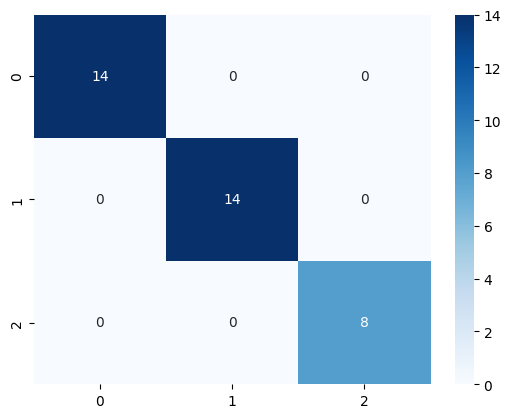

In [ ]:
import seaborn as sns
sns.heatmap(cm,annot = True, cmap = 'Blues')
plt.show()